<a href="https://colab.research.google.com/github/SULTAN096/Object-Detection-ITU/blob/main/week8_code_YOLO_where_is_it_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2: What is where, and what it costs to be wrong
**Industrial AI (IAI-26).

Last Class Notebook 1 asked what is in a picture. This one asks where. A detector
answers with boxes: four numbers, a class and a confidence, as many as it
finds. We will write the two pieces of arithmetic every detector rests on,
load one fine-tuned before the session on 1,132 construction-site photos, and
then read its score properly.

## Overview

The dataset is **construction-ppe** (Ultralytics, AGPL-3.0) [S4], published
as a construction-site PPE dataset of 1,416 photos (not every one is a site:
section 9 looks at some that are not), labelled with boxes for eleven
classes, which the setup cell prints. People; helmets, vests, gloves, boots
and goggles when they are worn; and `no_helmet`, `no_gloves`, `no_boots`,
`no_goggle` when the body part is bare. The eleventh, `none`, has the least
helpful name: its boxes sit on torsos with no vest on, so it is in effect a
missing vest, although its name does not start with `no_`.

A camera on a site gate is not bought to count helmets. It is bought to
catch the head that has none. Keep that sentence in mind while the numbers
arrive.

ℹ️ **Note:** Ultralytics YOLO [S1] is licensed **AGPL-3.0**. That is free to use
for coursework like this, and it is copyleft: a model you train with it
carries AGPL obligations with it, unless you buy an Ultralytics Enterprise
licence. Those obligations are not only about shipping a product. The
licence page lists, among the uses that need the Enterprise licence,
"Internal business tools or private company applications" and "SaaS
platforms, APIs, or cloud systems", even when YOLO is used "only internally
or for R&D" [S3]. If that is a problem where you work, **RF-DETR** [S18] is a
detector with a similar workflow whose Nano, Small, Medium and Large models
are Apache-2.0 (its XL and 2XL sizes are not). Say this out loud to your
manager before the pilot, not after.

### What you will learn

By the end of this notebook, you will be able to:
* Read a detection as what it is: four box numbers, a class id and a confidence.
* Compute IoU and run non-maximum suppression with code you wrote yourself.
* Walk a precision-recall curve down a sorted list of detections and get AP out of it.
* Fine-tune a detector on your own classes with three lines, and evaluate it honestly.
* Choose a confidence threshold by naming the two kinds of mistake it trades.

**What this notebook covers**

| Topic | Contents |
|---|---|
| 1. Setup | Versions, device, licence, and the paths this notebook reads. |
| 2. A detector you did not train | COCO's 80 classes meet a building site. |
| 3. What a box is | One prediction, printed number by number. |
| 4. IoU, by hand | Eight lines of arithmetic, and four checks. |
| 5. Non-maximum suppression, by hand | A dozen lines, and what YOLO26 changed. |
| 6. How a detector is scored | Real detections, sorted, walked, integrated. |
| 7. Fine-tune the detector | Three lines, switched off, and the checkpoint trained before the session. |
| 8. The number that matters | Per-class AP against per-class training boxes, and a leak in the split. |
| 9. Threshold theatre | Found, missed, false alarms, and the photos behind them. |
| 10. A different world | The same three lines on brain MRI and CT, and the honesty block. |

## 1. Setup

The first cell is the only one that installs or downloads anything, and it
does so only in Colab, if you open this notebook there after the session: it
installs Ultralytics and fetches the two datasets and the pretrained weights
from the publisher. On this machine it installs nothing and downloads nothing,
because `prep_data.py` already put everything in `../data`.

One thing no cell fetches: the two checkpoints trained before the session,
which sections 7 and 10 load wherever the notebook runs. In Colab, upload
`ppe_yolo26n_10ep.pt`, `ppe_yolo26n_10ep.json`, `brain_yolo26n_10ep.pt` and
`brain_yolo26n_10ep.json` from the course folder's `assets/` into the file
panel before section 7; if they are missing, section 7 stops and names them.

In [ ]:
# Colab only: install what Colab lacks and fetch the data. Local: do nothing.
import subprocess
import sys
import urllib.request
import zipfile
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

RELEASE = "https://github.com/ultralytics/assets/releases/download"
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "ultralytics==8.4.159"], check=True)
    DATA = Path("datasets")
    DATA.mkdir(exist_ok=True)
    for name, tag in [("construction-ppe", "v0.0.0"), ("brain-tumor", "v0.0.0")]:
        if not (DATA / name).exists():
            zip_path = DATA / f"{name}.zip"
            urllib.request.urlretrieve(f"{RELEASE}/{tag}/{name}.zip", zip_path)
            # These archives have no top folder of their own, so give each one its own.
            with zipfile.ZipFile(zip_path) as archive:
                archive.extractall(DATA / name)
    (DATA / "weights").mkdir(exist_ok=True)
    if not (DATA / "weights" / "yolo26n.pt").exists():
        urllib.request.urlretrieve(f"{RELEASE}/v8.4.0/yolo26n.pt",
                                   DATA / "weights" / "yolo26n.pt")
else:
    DATA = Path("../data")
# Relative to this notebook, on purpose: a full path would print your home folder.
print(f"running on Colab: {IN_COLAB} · data folder: {DATA}")

running on Colab: True · data folder: datasets


Now the imports, the versions the numbers below were measured on, and the
device. Four rules are set here and honoured everywhere after:

* `settings.update({"sync": False})` switches off the anonymous usage
  analytics Ultralytics sends home by default. No record of this run is sent
  anywhere.
* `YOLO_VERBOSE` is set to `False` before Ultralytics is imported, so its
  banners and progress bars stay off the screen: they print the folders of
  whoever runs the notebook. Errors still print.
* The publisher's dataset yaml says `path: construction-ppe`, which
  Ultralytics resolves against a datasets folder it reads from its global
  settings, once, when it is imported. On a machine whose settings point
  anywhere else, validation would download the whole archive. So this cell
  writes a copy of each yaml into `out/` with the full path filled in, every
  call below reads that copy, and the datasets folder in your Ultralytics
  settings is left as it was.
* **Every cell below runs on `cpu`** (or on `cuda` when there is a GPU),
  never on `mps`. The reason is narrower than it sounds. In Ultralytics
  issue 24399 [S33], the validation Ultralytics printed *during* training on
  `mps` disagreed with a separate validation of the same checkpoint, while
  that checkpoint, validated on its own, scored the same mAP50 on `mps` and
  on `cpu`. So no number here is read off a training log: every one comes
  from a separate validation run, and running them all on one device is a
  choice for consistency, not a verdict on `mps`.
  `DEVICE` below is still worth printing: it is the answer to "what would
  serve this model here", and on a Mac it is `mps`.

In [ ]:
# Imports, versions, device, and the Ultralytics settings that matter.
import json
import os
import shutil
import time

# Before the first ultralytics import: no banners or progress bars. They print the
# folders of whoever runs this notebook. Errors still print.
os.environ["YOLO_VERBOSE"] = "False"

import matplotlib.pyplot as plt
import numpy as np
import torch
import ultralytics
import yaml
from matplotlib.patches import Rectangle
from PIL import Image
from ultralytics import YOLO, settings
from ultralytics.utils import DEFAULT_CFG

settings.update({"sync": False})

# What this machine would serve the model on, if speed were the only concern.
DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
# What every metric is computed on: one device throughout, never a training log [S33].
METRIC_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# The checkpoints trained before the session. Every device loads them (section 7).
SHIPPED = ["ppe_yolo26n_10ep.pt", "ppe_yolo26n_10ep.json",
           "brain_yolo26n_10ep.pt", "brain_yolo26n_10ep.json"]


def shipped_folder():
    """The first folder holding all four shipped files: ../assets, assets/, or here."""
    for folder in (Path("../assets"), Path("assets"), Path(".")):
        if all((folder / name).exists() for name in SHIPPED):
            return folder
    raise FileNotFoundError(
        "the shipped checkpoints are missing. Upload these four files from the "
        f"course folder's assets/ into Colab's file panel, then run this cell "
        f"again: {', '.join(SHIPPED)}")


def absolute_yaml(source):
    """A copy of a dataset yaml in out/, with an absolute `path:` nobody can misread."""
    spec = yaml.safe_load(source.read_text())
    spec["path"] = str(source.parent.resolve())
    target = OUT / source.name
    target.write_text(yaml.safe_dump(spec, sort_keys=False))
    return target


# Absolute on purpose: Ultralytics files a relative project folder under runs/detect/.
OUT = Path("out").resolve()
OUT.mkdir(exist_ok=True)
PPE = DATA / "construction-ppe"
PPE_YAML = PPE / "data.yaml"
PPE_NAMES = yaml.safe_load(PPE_YAML.read_text())["names"]
# What every Ultralytics call below reads: the copies with the full path filled in.
PPE_DATA = absolute_yaml(PPE_YAML)
BRAIN_DATA = absolute_yaml(DATA / "brain-tumor" / "brain-tumor.yaml")
WEIGHTS = DATA / "weights" / "yolo26n.pt"
TEST_IMAGES = PPE / "images" / "test"
TEST_LABELS = PPE / "labels" / "test"
TRAIN_LABELS = PPE / "labels" / "train"

print(f"ultralytics {ultralytics.__version__} · torch {torch.__version__} · "
      f"numpy {np.__version__}")
print(f"this machine would serve on: {DEVICE} · "
      f"every cell below runs on: {METRIC_DEVICE}")
split_sizes = {split: len(list((PPE / "images" / split).iterdir()))
               for split in ("train", "val", "test")}
print(f"construction-ppe photos: {split_sizes}, "
      f"{sum(split_sizes.values())} in total")
print(f"its {len(PPE_NAMES)} classes: {PPE_NAMES}")
print(f"weights file: {WEIGHTS.name}, "
      f"{WEIGHTS.stat().st_size / 1e6:.1f} MB on disk")

ultralytics 8.4.159 · torch 2.11.0+cu130 · numpy 2.1.3
this machine would serve on: cuda · every cell below runs on: cuda
construction-ppe photos: {'train': 1132, 'val': 143, 'test': 141}, 1416 in total
its 11 classes: {0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles', 5: 'none', 6: 'Person', 7: 'no_helmet', 8: 'no_goggle', 9: 'no_gloves', 10: 'no_boots'}
weights file: yolo26n.pt, 5.5 MB on disk


## 2. A detector you did not train

`yolo26n.pt` is the smallest YOLO26, pretrained on COCO: everyday
photographs labelled with a fixed list of everyday classes. It has never
seen a construction site from this dataset. We will point it at three site
photos and look at what comes back, and at what does not.

> 🔮 **Predict first:** it was trained on 80 everyday classes. Which of these
> does it know: **person**, **helmet**, **high-visibility vest**?

In [ ]:
str(WEIGHTS)

'datasets/weights/yolo26n.pt'

In [ ]:
TEST_IMAGES

PosixPath('datasets/construction-ppe/images/test')

In [ ]:
# A COCO-pretrained detector, three site photos, and the words it has available.
SHOTS = ["image796.jpg", "image1037.jpeg", "image167.jpg"]
coco_model = YOLO(str(WEIGHTS))
started = time.perf_counter()
coco_results = coco_model.predict([str(TEST_IMAGES / s) for s in SHOTS],
                                  device=METRIC_DEVICE, conf=0.25, verbose=False)
elapsed = time.perf_counter() - started
print(f"{len(SHOTS)} photos through YOLO26n in {elapsed:.1f} s on {METRIC_DEVICE}")
print(f"classes this model knows: {len(coco_model.names)}")
wanted = ["person", "helmet", "vest", "glove", "boot", "goggles", "hard hat"]
for word in wanted:
    hits = [name for name in coco_model.names.values() if word in name]
    print(f"  COCO classes containing {word!r}: {hits if hits else 'NONE'}")

3 photos through YOLO26n in 0.2 s on cuda
classes this model knows: 80
  COCO classes containing 'person': ['person']
  COCO classes containing 'helmet': NONE
  COCO classes containing 'vest': NONE
  COCO classes containing 'glove': ['baseball glove']
  COCO classes containing 'boot': NONE
  COCO classes containing 'goggles': NONE
  COCO classes containing 'hard hat': NONE


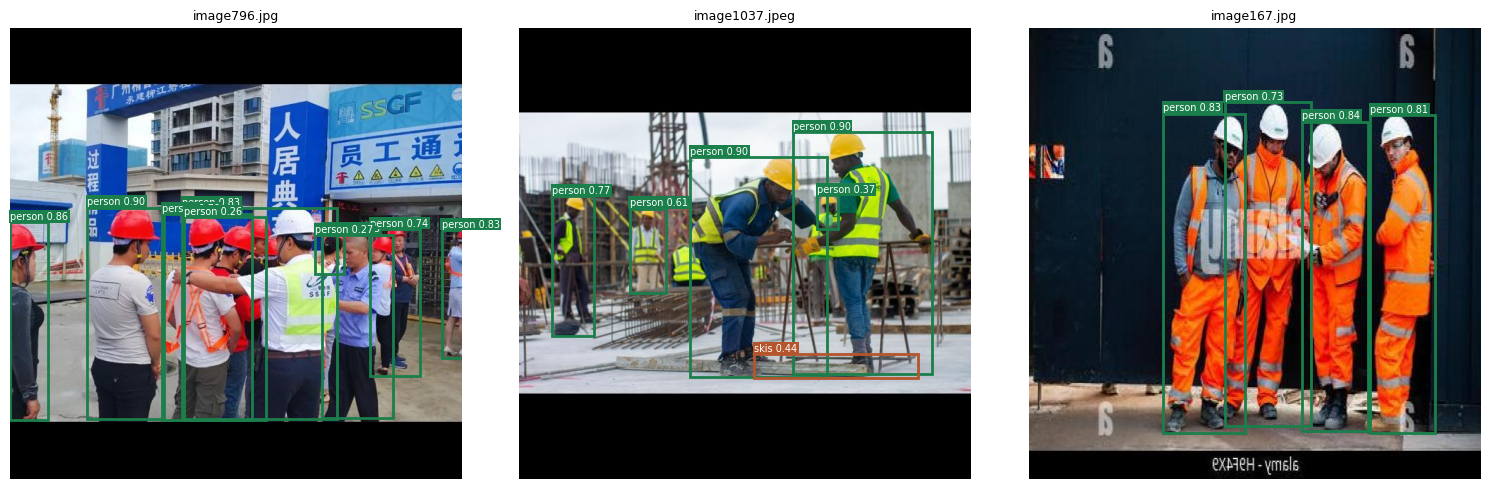

classes that fired across the three photos: {'person': 18, 'skis': 1}


In [ ]:
# What actually fired, and where. Colours per class, drawn with matplotlib so that
# every box on screen is four numbers you could have printed yourself.
PALETTE = ["#1b7f4b", "#b4552d", "#2f5d8a", "#8a6d2f", "#7a2f5d", "#3f7a7a"]
CLASS_COLOUR = {}


def draw(axis, image_path, boxes, labels, title):
    """Show an image with one labelled rectangle per box, boxes given as xyxy."""
    axis.imshow(np.asarray(Image.open(image_path).convert("RGB")))
    for box, label in zip(boxes, labels):
        # One colour per class name, handed out in the order the names first appear.
        key = str(label).split()[0]
        colour = CLASS_COLOUR.setdefault(
            key, PALETTE[len(CLASS_COLOUR) % len(PALETTE)])
        axis.add_patch(Rectangle((box[0], box[1]), box[2] - box[0],
                                 box[3] - box[1], fill=False, lw=2,
                                 edgecolor=colour))
        axis.text(box[0], box[1] - 4, label, fontsize=7, color="white",
                  bbox={"facecolor": colour, "pad": 1, "edgecolor": "none"})
    axis.set_title(title, fontsize=9)
    axis.axis("off")


fired = {}
figure, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, shot, result in zip(axes, SHOTS, coco_results):
    names = [coco_model.names[int(c)] for c in result.boxes.cls]
    for name in names:
        fired[name] = fired.get(name, 0) + 1
    labels = [f"{n} {float(s):.2f}"
              for n, s in zip(names, result.boxes.conf)]
    draw(axis, TEST_IMAGES / shot, result.boxes.xyxy.cpu().numpy(), labels, shot)
plt.tight_layout()
plt.show()
print(f"classes that fired across the three photos: {fired}")

Read the printout above, then the picture. The model finds people, and it
finds them confidently. Now find any class in the printout that is not
`person`, and find its box in the picture: when it meets something it has
no word for, it reaches for the nearest word it does have.

It did not miss the helmets. **It has no word for helmet.** Read the search
above: COCO's 80 classes were chosen for everyday photographs, so `helmet`,
`vest`, `boots` and `goggles` are simply not in the list, and the nearest
thing it has to a glove belongs on a baseball field. No confidence
threshold, no bigger backbone and no better camera fixes that. The only fix
is to teach it the words, which is section 7.

## 3. What a box is

Strip the drawing away. A detection is a row of numbers. Ultralytics hands
them back in three forms, and you will meet all three in your career, so
here they are side by side on one real prediction:

* `xyxy`: left, top, right, bottom, in pixels. Easiest to reason about.
* `xywh`: centre x, centre y, width, height, in pixels.
* normalised `xywhn`: the same as `xywh`, divided by image width and height,
  so every number is between 0 and 1. This is the **YOLO label format**: the
  `.txt` file next to each training image holds `class cx cy w h`, one line
  per object, with no image size anywhere in it.

Until section 7 we keep using the COCO model from section 2, and the one
class it shares with this dataset: a person.

In [ ]:
# One photo, one prediction, printed as numbers before it is drawn.
ONE_SHOT = TEST_IMAGES / "image116.jpg"
one = coco_model.predict(str(ONE_SHOT), device=METRIC_DEVICE, conf=0.25,
                         verbose=False)[0]
print(f"image {one.orig_shape} (height, width) · {len(one.boxes)} detections")
print(f"boxes.xyxy {tuple(one.boxes.xyxy.shape)} {one.boxes.xyxy.dtype} on "
      f"{one.boxes.xyxy.device} · conf {tuple(one.boxes.conf.shape)} · "
      f"cls {tuple(one.boxes.cls.shape)}")
row = 0
print(f"\ndetection {row}:")
print(f"  class id   {int(one.boxes.cls[row])} -> "
      f"{one.names[int(one.boxes.cls[row])]}")
print(f"  confidence {float(one.boxes.conf[row]):.4f}")
print(f"  xyxy       {[round(float(v), 1) for v in one.boxes.xyxy[row]]}")
print(f"  xywh       {[round(float(v), 1) for v in one.boxes.xywh[row]]}")
print(f"  xywhn      {[round(float(v), 4) for v in one.boxes.xywhn[row]]}")
label_file = TEST_LABELS / f"{ONE_SHOT.stem}.txt"
print(f"\nthe ground-truth label file {label_file.name}, first two lines:")
for line in label_file.read_text().strip().split("\n")[:2]:
    print(f"  {line}    <- class {line.split()[0]} is "
          f"{PPE_NAMES[int(line.split()[0])]} in this dataset")

image (640, 640) (height, width) · 4 detections
boxes.xyxy (4, 4) torch.float32 on cuda:0 · conf (4,) · cls (4,)

detection 0:
  class id   0 -> person
  confidence 0.9131
  xyxy       [36.0, 192.9, 216.4, 576.6]
  xywh       [126.2, 384.7, 180.4, 383.7]
  xywhn      [0.1971, 0.6011, 0.2818, 0.5995]

the ground-truth label file image116.txt, first two lines:
  6 0.219695 0.554008 0.327047 0.709953    <- class 6 is Person in this dataset
  1 0.671008 0.411266 0.067109 0.043281    <- class 1 is gloves in this dataset


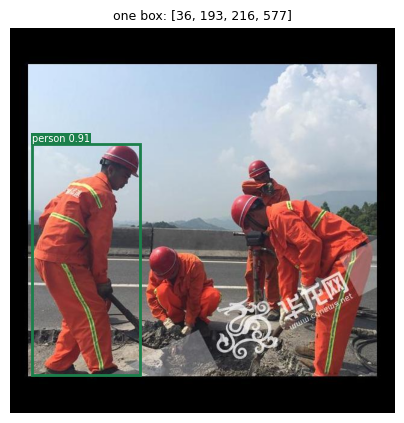

In [ ]:
# The same detection, drawn. The rectangle is those four xyxy numbers, nothing more.
figure, axis = plt.subplots(figsize=(5, 5))
box = one.boxes.xyxy[row].cpu().numpy()
draw(axis, ONE_SHOT, [box],
     [f"{one.names[int(one.boxes.cls[row])]} {float(one.boxes.conf[row]):.2f}"],
     f"one box: {[round(float(v)) for v in box]}")
plt.show()

Notice that a class id is only a position in a list of names. The COCO
model and this dataset's label files both number a person, with different
numbers; nothing but each one's own names list says what an id means. Mix
up two lists and every box is confidently mislabelled.

ℹ️ **Note:** the boxes come back as a `torch.float32` tensor on the device
the model ran on, which the shape line above prints. `.cpu().numpy()` is what
moves them into plain numpy for drawing and arithmetic; every function we
write below works on numpy arrays or plain lists.

## 4. IoU, by hand

Two boxes point at the same thing when they overlap enough. "Enough" needs a
number, and the number the whole field uses is **Intersection over Union**:
the area both boxes cover, divided by the area either of them covers.

It is eight lines of arithmetic. Write it once and you own every threshold
argument you will ever have with a vendor.

In [ ]:
def iou(box_a, box_b):
    """Intersection over union of two xyxy boxes. 1.0 identical, 0.0 disjoint."""
    left = max(box_a[0], box_b[0])
    top = max(box_a[1], box_b[1])
    right = min(box_a[2], box_b[2])
    bottom = min(box_a[3], box_b[3])
    # A negative width or height means the boxes miss each other entirely.
    overlap = max(0.0, right - left) * max(0.0, bottom - top)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    return overlap / (area_a + area_b - overlap)


CASES = [("identical", [0, 0, 10, 10], [0, 0, 10, 10]),
         ("half overlap", [0, 0, 10, 10], [5, 0, 15, 10]),
         ("corner touch", [0, 0, 10, 10], [5, 5, 15, 15]),
         ("disjoint", [0, 0, 10, 10], [20, 20, 30, 30])]
for name, box_a, box_b in CASES:
    print(f"{name:>13}: iou = {iou(box_a, box_b):.4f}")

    identical: iou = 1.0000
 half overlap: iou = 0.3333
 corner touch: iou = 0.1429
     disjoint: iou = 0.0000


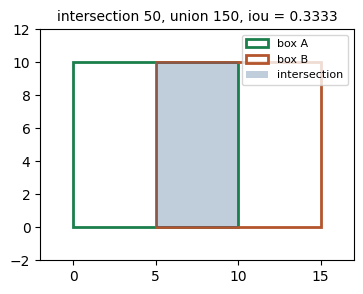

In [ ]:
# The half-overlap case, drawn, with the intersection shaded.
name, box_a, box_b = CASES[1]
left, right = max(box_a[0], box_b[0]), min(box_a[2], box_b[2])
top, bottom = max(box_a[1], box_b[1]), min(box_a[3], box_b[3])
overlap = (right - left) * (bottom - top)
union = ((box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
         + (box_b[2] - box_b[0]) * (box_b[3] - box_b[1]) - overlap)
figure, axis = plt.subplots(figsize=(5, 3))
for box, colour, label in [(box_a, PALETTE[0], "box A"), (box_b, PALETTE[1], "box B")]:
    axis.add_patch(Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                             fill=False, lw=2, edgecolor=colour, label=label))
axis.add_patch(Rectangle((left, top), right - left, bottom - top,
                         facecolor=PALETTE[2], alpha=0.3, label="intersection"))
axis.set_xlim(-2, 17)
axis.set_ylim(-2, 12)
axis.set_aspect("equal")
axis.legend(fontsize=8, loc="upper right")
axis.set_title(f"intersection {overlap}, union {union}, "
               f"iou = {iou(box_a, box_b):.4f}", fontsize=10)
plt.show()

Two boxes that share half their width score 0.33, not 0.5. IoU punishes the
part of each box the other one misses, twice over. That is why **0.5 is a
loose standard**, and why the same detector scores so much lower when it is
held to stricter overlaps: sections 6 and 7 live on this.

## 5. Non-maximum suppression, by hand

A detector does not produce one box per object. It produces a box from every
place in the image that looks promising, so a single person arrives as a
small pile of nearly identical boxes with slightly different confidences.
**Non-maximum suppression** is the clean-up: take the most confident box,
throw away everything that overlaps it too much, repeat.

Below we ask Ultralytics to suppress almost nothing (`iou=0.99`) so that the
pile survives, then run our own NMS on it.

> 🔮 **Predict first:** the photo from section 3 has a few people in it. The
> model will hand us a pile of overlapping person boxes. How many do you
> think survive an NMS at IoU 0.5?

In [ ]:
def nms(boxes, scores, iou_threshold):
    """Greedy non-maximum suppression. Returns the indices of the boxes kept."""
    # 1. Sort every candidate by confidence, most confident first.
    order = list(np.argsort(-np.asarray(scores)))
    kept = []
    while order:
        # 2. The most confident candidate left always survives.
        best = order.pop(0)
        kept.append(best)
        # 3. Anything that overlaps it by more than the threshold is the same
        #    object seen again, so drop it and never look at it again.
        order = [j for j in order if iou(boxes[best], boxes[j]) < iou_threshold]
    # 4. What is left is one box per object, each the best of its pile.
    return kept


# The pile: person candidates from one photo, with Ultralytics' own NMS all but off.
COCO_PERSON = [i for i, n in coco_model.names.items() if n == "person"][0]
PPE_PERSON = [i for i, n in PPE_NAMES.items() if n == "Person"][0]
piled = coco_model.predict(str(ONE_SHOT), device=METRIC_DEVICE, conf=0.25,
                           iou=0.99, verbose=False)[0]
is_person = (piled.boxes.cls == COCO_PERSON).cpu().numpy()
candidates = piled.boxes.xyxy.cpu().numpy()[is_person]
confidences = piled.boxes.conf.cpu().numpy()[is_person]
print(f"candidate boxes {candidates.shape} · scores {confidences.shape}")
survivors = nms(candidates, confidences, iou_threshold=0.5)
print(f"our nms at IoU 0.5 keeps {len(survivors)} of {len(candidates)}")
ultralytics_own = coco_model.predict(str(ONE_SHOT), device=METRIC_DEVICE,
                                     conf=0.25, verbose=False)[0]
own_people = int((ultralytics_own.boxes.cls == COCO_PERSON).sum())
print(f"Ultralytics' own NMS, at its default IoU {DEFAULT_CFG.iou}, on the same photo "
      f"keeps {own_people}")
label_ids = [line.split()[0] for line in label_file.read_text().split("\n")
             if line.strip()]
print(f"people the annotators boxed in this photo: "
      f"{label_ids.count(str(PPE_PERSON))}")

candidate boxes (19, 4) · scores (19,)
our nms at IoU 0.5 keeps 4 of 19
Ultralytics' own NMS, at its default IoU 0.7, on the same photo keeps 4
people the annotators boxed in this photo: 4


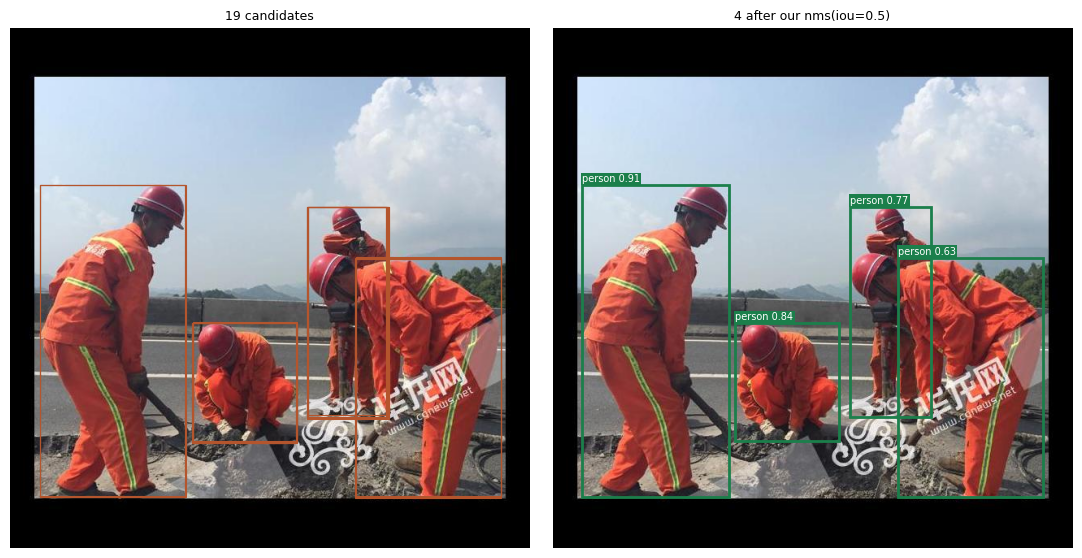

In [ ]:
# Before and after, side by side. The pile is drawn thin and unlabelled, because
# its boxes sit almost exactly on top of each other.
figure, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(np.asarray(Image.open(ONE_SHOT).convert("RGB")))
for box in candidates:
    axes[0].add_patch(Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                fill=False, lw=0.8, edgecolor=PALETTE[1]))
axes[0].set_title(f"{len(candidates)} candidates", fontsize=9)
axes[0].axis("off")
draw(axes[1], ONE_SHOT, candidates[survivors],
     [f"person {confidences[i]:.2f}" for i in survivors],
     f"{len(survivors)} after our nms(iou=0.5)")
plt.tight_layout()
plt.show()

Our dozen lines returned the same count as the library's. That is the whole
of NMS: there is no cleverness hiding in the C++. The two did not use the
same threshold, though: ours dropped a box at IoU 0.5, and the library's
default, printed above, is 0.7, which lets more overlap survive. On this
photo the two thresholds happen to agree; on a crowded one they can differ.

**Note.** YOLO26 does not have to run NMS at all. Its detection
head is a dual head: the default one-to-many path produces the usual pile
and needs NMS, and a second one-to-one path "**Produces end-to-end
predictions without NMS**" when you pass `nms=False` [S2]. The documentation
is equally plain that "**Prediction and validation default to the
one-to-many head for accuracy**" [S2], so the default path you just ran, and
everything measured in this notebook, does use NMS.

Learn NMS anyway. Most detectors running in production today still run it:
YOLO26 was released in January 2026 [S2], and anything exported before
then, or built on another family, carries this step in its post-processing,
which is where duplicate alarms are won and lost.

In [ ]:
# The four photos seen so far through both heads, counting detections of every class.
# The no-NMS head gets a copy of its own: Ultralytics remembers nms=False on the model
# it was passed to, and coco_model must stay on the default head for section 6.
one_to_one = YOLO(str(WEIGHTS))
four_shots = [ONE_SHOT] + [TEST_IMAGES / s for s in SHOTS]
agree = 0
print(f"{'photo':>14} {'default head, NMS':>18} {'nms=False, no NMS':>18}")
for path in four_shots:
    with_nms = coco_model.predict(str(path), device=METRIC_DEVICE, conf=0.25,
                                  verbose=False)[0]
    no_nms = one_to_one.predict(str(path), device=METRIC_DEVICE, conf=0.25,
                                nms=False, verbose=False)[0]
    agree += len(with_nms.boxes) == len(no_nms.boxes)
    print(f"{path.name:>14} {len(with_nms.boxes):>18} {len(no_nms.boxes):>18}")
print(f"the two heads report the same count on {agree} of {len(four_shots)} photos")

         photo  default head, NMS  nms=False, no NMS
  image116.jpg                  4                  4
  image796.jpg                  9                  9
image1037.jpeg                  6                  6
  image167.jpg                  4                  4
the two heads report the same count on 4 of 4 photos


Read the last line. Where the counts agree, the one-to-one head has done the
clean-up's job with no clean-up pass: it was trained to put one box on each
object by itself. Where they differ, neither is the correct one: the heads
are trained together but they are not the same function. Either way, what
the switch buys you is whether a post-processing pass has to run at all,
which is a deployment question more than an accuracy one.

## 6. How a detector is scored

This is the one piece of arithmetic in the notebook. Everything a vendor
will ever quote you rests on it.

A detection is a **true positive** if it has the right class and overlaps a
ground-truth box of that class by IoU 0.5 or more, and that ground-truth box
has not already been claimed by a more confident detection. Everything else
is a **false positive**. Then:

1. Sort every detection of the class by confidence, highest first.
2. Walk down the list. After each row, precision is the share of the rows so
   far that were true positives, and recall is the share of all ground-truth
   boxes found so far.
3. Those pairs trace a **precision-recall curve**. Its area is the
   **average precision**, AP.

We do it on real detections and real labels: the COCO model's `person`
boxes on four test photos, scored against the `Person` boxes this dataset's
annotators drew. Nothing in the table is made up for the example.

In [ ]:
def ground_truth(stem, class_id, width, height):
    """Read the YOLO label file for one image and return xyxy boxes of one class."""
    boxes = []
    for line in (TEST_LABELS / f"{stem}.txt").read_text().strip().split("\n"):
        parts = line.split()
        if not parts or int(parts[0]) != class_id:
            continue
        centre_x, centre_y, box_w, box_h = (float(v) for v in parts[1:5])
        boxes.append([(centre_x - box_w / 2) * width, (centre_y - box_h / 2) * height,
                      (centre_x + box_w / 2) * width, (centre_y + box_h / 2) * height])
    return np.array(boxes, dtype=float).reshape(-1, 4)


FOUR = ["image1.jpeg", "image10.jpeg", "image110.jpg", "image149.jpg"]
worked = coco_model.predict([str(TEST_IMAGES / f) for f in FOUR],
                            device=METRIC_DEVICE, conf=0.10, verbose=False)
detections, truth, n_truth = [], {}, 0
for shot, result in zip(FOUR, worked):
    shot_h, shot_w = result.orig_shape
    truth[shot] = ground_truth(Path(shot).stem, PPE_PERSON, shot_w, shot_h)
    n_truth += len(truth[shot])
    keep = (result.boxes.cls == COCO_PERSON).cpu().numpy()
    for box, conf in zip(result.boxes.xyxy.cpu().numpy()[keep],
                         result.boxes.conf.cpu().numpy()[keep]):
        detections.append((shot, box, float(conf)))
# 1. Sort by confidence, most confident first.
detections.sort(key=lambda row: -row[2])
print(f"{n_truth} labelled people in {len(FOUR)} photos · "
      f"{len(detections)} person detections at conf >= 0.10")

claimed = {shot: set() for shot in FOUR}
hits = np.zeros(len(detections))
print(f"\n{'#':>2} {'photo':>14} {'conf':>6} {'best IoU':>9} {'verdict':>8} "
      f"{'precision':>10} {'recall':>7}")
for index, (shot, box, conf) in enumerate(detections):
    # 2. Score this detection against every unclaimed ground-truth box of its class.
    overlaps = [iou(box, gt) for gt in truth[shot]]
    best = int(np.argmax(overlaps)) if overlaps else -1
    # 3. A true positive needs IoU >= 0.5 AND a ground-truth box nobody claimed yet.
    hit = best >= 0 and overlaps[best] >= 0.5 and best not in claimed[shot]
    if hit:
        claimed[shot].add(best)
    hits[index] = hit
    # 4. Precision and recall, recomputed from the top of the list to here.
    precision = hits[:index + 1].sum() / (index + 1)
    recall = hits[:index + 1].sum() / n_truth
    print(f"{index + 1:>2} {shot:>14} {conf:>6.3f} "
          f"{(max(overlaps) if overlaps else 0.0):>9.3f} "
          f"{'TP' if hit else 'FP':>8} {precision:>10.3f} {recall:>7.3f}")

11 labelled people in 4 photos · 12 person detections at conf >= 0.10

 #          photo   conf  best IoU  verdict  precision  recall
 1    image1.jpeg  0.909     0.837       TP      1.000   0.091
 2   image10.jpeg  0.906     0.805       TP      1.000   0.182
 3   image149.jpg  0.904     0.812       TP      1.000   0.273
 4   image149.jpg  0.870     0.605       TP      1.000   0.364
 5   image10.jpeg  0.850     0.465       FP      0.800   0.364
 6   image10.jpeg  0.844     0.727       TP      0.833   0.455
 7   image110.jpg  0.815     0.750       TP      0.857   0.545
 8   image149.jpg  0.758     0.813       TP      0.875   0.636
 9   image110.jpg  0.741     0.838       TP      0.889   0.727
10   image149.jpg  0.734     0.037       FP      0.800   0.727
11   image110.jpg  0.734     0.732       TP      0.818   0.818
12   image149.jpg  0.131     0.060       FP      0.750   0.818


precision (12,) · recall (12,)
AP50 for person on these 4 photos: 0.8292


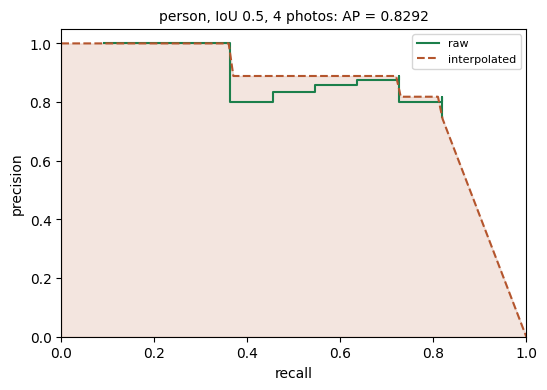

In [ ]:
# The curve those pairs trace, and its area.
found = np.cumsum(hits)
precision = found / np.arange(1, len(detections) + 1)
recall = found / n_truth
print(f"precision {precision.shape} · recall {recall.shape}")
# Pad the ends, then make precision non-increasing: at any recall, the best
# precision still achievable to its right. This is the standard interpolation.
padded_precision = np.concatenate([[1.0], precision, [0.0]])
padded_recall = np.concatenate([[0.0], recall, [1.0]])
padded_precision = np.maximum.accumulate(padded_precision[::-1])[::-1]
# Sample the curve at 101 evenly spaced recalls and take the area (trapezoid rule).
grid = np.linspace(0, 1, 101)
sampled = np.interp(grid, padded_recall, padded_precision)
ap50_person = float(np.sum((grid[1:] - grid[:-1])
                           * (sampled[1:] + sampled[:-1]) / 2))
print(f"AP50 for person on these {len(FOUR)} photos: {ap50_person:.4f}")

figure, axis = plt.subplots(figsize=(6, 4))
axis.step(recall, precision, where="post", color=PALETTE[0], label="raw")
axis.plot(grid, sampled, color=PALETTE[1], ls="--", label="interpolated")
axis.fill_between(grid, sampled, alpha=0.15, color=PALETTE[1])
axis.set_xlabel("recall")
axis.set_ylabel("precision")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1.05)
axis.set_title(f"person, IoU 0.5, {len(FOUR)} photos: AP = {ap50_person:.4f}",
               fontsize=10)
axis.legend(fontsize=8)
plt.show()

Three things to look for in the table before moving on.

* A confident row marked **FP** with a best IoU just under 0.5. The model
  found a person there; it drew the box differently from the annotator, and
  at IoU 0.5 that counts as wrong. The threshold is a convention, not a law.
* A confident row marked **FP** with a best IoU near 0: a box where the
  annotators drew no person at all. Either the model imagined one or the
  annotator missed one. The score cannot tell which; only the photo can.
* Where recall stops climbing. People the model never boxed cap recall below
  1, and no amount of walking down the list recovers them.

A second box on a person already claimed would also be an **FP**, which is
why section 5's clean-up is a scoring matter and not a cosmetic one.

That number is AP for one class at one IoU threshold, over four photos.
Scale it up and you have the two names on every detector datasheet:

* **mAP50** is that AP, averaged over all classes, at IoU 0.5.
* **mAP50-95** averages it again over ten IoU thresholds, 0.50, 0.55, up to
  0.95. In practice it is the smaller number, because a box that was good
  enough at 0.5 usually is not at 0.9. When a vendor quotes you one number,
  ask which.

ℹ️ **Note:** COCO, whose evaluation everyone copied, says on its own
evaluation page that it makes no distinction between AP and mAP and assumes
the difference is clear from context [S6]. So read the IoU threshold and the
class list, not the letter m.

## 7. Fine-tune the detector

Three lines do the work. Load a COCO-pretrained model, train it on a dataset
yaml that lists your classes, validate it:

```python
model = YOLO(weights)
model.train(data=yaml, epochs=10, imgsz=640)
model.val(data=yaml, split="test")
```

The cell below is those three lines, in the open and switched off. **It
loads the checkpoint shipped with the session**, trained before the session
with the same three lines, 10 epochs on 1,132 photos, so every run of this
notebook scores the same model. One setting differs between that run and the
live branch below: it loaded its images with `workers=4`, the branch below
uses `workers=2`. The cell prints how long that training took: that number is
this Mac's `mps` wall clock, a Mac's GPU, and it is time the afternoon does
not have. Nobody has timed the same run on a Colab GPU, so if you set
`TRAIN_LIVE = True` there, this notebook cannot tell you what to expect.

In [ ]:
# The fine-tune. Every run loads the shipped checkpoint, so every screen scores the
# same model. The three lines stay here, switched off: TRAIN_LIVE = True on a GPU
# runtime retrains it, for a time nobody has measured off this Mac's mps.
EPOCHS = 10
TRAIN_LIVE =  False
root = ""
ASSETS = shipped_folder()
started = time.perf_counter()
if TRAIN_LIVE:
    model = YOLO(str(WEIGHTS))
    model.train(data=str(PPE_DATA), epochs=EPOCHS, imgsz=640, batch=16,
                device=DEVICE, seed=0, deterministic=True, workers=2,
                project=str(OUT), name="ppe", exist_ok=True, plots=False)
    print(model.trainer.best)
    detector = YOLO(str(model.trainer.best))
    print(f"trained here: {EPOCHS} epochs on {DEVICE} in "
          f"{time.perf_counter() - started:.0f} s")
else:
    detector = YOLO(str(ASSETS / "ppe_yolo26n_10ep.pt"))

    print(f"TRAIN_LIVE is off, so nothing was trained: loaded the shipped "
          f"checkpoint {ASSETS / 'ppe_yolo26n_10ep.pt'} "
          f"({EPOCHS} epochs, imgsz 640, batch 16, seed 0) in "
          f"{time.perf_counter() - started:.1f} s")
    # The record written when the checkpoint was made, before the session.
    record = json.loads((ASSETS / "ppe_yolo26n_10ep.json").read_text())
    print(f"that training took {record['train_seconds']:.0f} s on "
          f"{record['trained_on']}, before the session")
print(f"classes it now knows: {len(detector.names)} -> "
      f"{list(detector.names.values())}")

TRAIN_LIVE is off, so nothing was trained: loaded the shipped checkpoint ppe_yolo26n_10ep.pt (10 epochs, imgsz 640, batch 16, seed 0) in 0.1 s
that training took 896 s on mps, before the session
classes it now knows: 11 -> ['helmet', 'gloves', 'vest', 'boots', 'goggles', 'none', 'Person', 'no_helmet', 'no_goggle', 'no_gloves', 'no_boots']


Now score it, on the **test** split it never saw during training, with the
metric device set in section 1. The cell prints how long that took.

> 🔮 **Predict first:** eleven classes, 1,132 training photos, 10 epochs.
> What mAP50 do you expect? And which class do you expect to be the worst?

In [ ]:
# Validate on the held-out test split. Every number below comes from this call.
started = time.perf_counter()
metrics = detector.val(data=str(PPE_DATA), split="test", device=METRIC_DEVICE,
                       plots=False, verbose=False, project=str(OUT),
                       name="val_test", exist_ok=True)
val_seconds = time.perf_counter() - started
map50 = float(metrics.box.map50)
map50_95 = float(metrics.box.map)
ap50 = {metrics.names[int(c)]: float(a)
        for c, a in zip(metrics.box.ap_class_index, metrics.box.ap50)}
print(f"validated on {METRIC_DEVICE} in {val_seconds:.1f} s")
print(f"test mAP50 {map50:.4f} · test mAP50-95 {map50_95:.4f}")
print(f"\n{'class':>10} {'AP50':>8}")
for name, value in sorted(ap50.items(), key=lambda kv: -kv[1]):
    print(f"{name:>10} {value:>8.4f}")

validated on cuda in 3.0 s
test mAP50 0.5065 · test mAP50-95 0.2507

     class     AP50
    helmet   0.9234
      vest   0.9056
    Person   0.8280
     boots   0.7580
    gloves   0.7397
   goggles   0.7264
      none   0.4152
 no_helmet   0.1181
 no_gloves   0.1039
 no_goggle   0.0533
  no_boots   0.0000


## 8. The number that matters is not the headline

Read the table you just printed from the bottom up.

The headline mAP50 is the average of eleven numbers that are nothing like
each other. The classes for equipment that is **worn** are near the top. The
four classes that begin with `no_`, for equipment that is **absent**, are at
the bottom, and they are the ones a site camera exists to find. Averaging
them together produces a number that is true and useless.

The next cell counts the training boxes of each class and puts the two
columns side by side.

In [ ]:
# Count every training box, by class, straight from the label files.
counts = {name: 0 for name in detector.names.values()}
train_images = {path.stem for path in (PPE / "images" / "train").iterdir()}
n_label_files = 0
for label_file in sorted(TRAIN_LABELS.glob("*.txt")):
    # Ultralytics pairs labels to images, so a label file with no image trains nothing.
    if label_file.stem not in train_images:
        continue
    n_label_files += 1
    for line in label_file.read_text().strip().split("\n"):
        parts = line.split()
        if parts:
            counts[detector.names[int(parts[0])]] += 1
print(f"{n_label_files} training images, {sum(counts.values())} boxes in total")
print(f"\n{'class':>10} {'train boxes':>12} {'test AP50':>10}")
for name, value in sorted(ap50.items(), key=lambda kv: -kv[1]):
    print(f"{name:>10} {counts[name]:>12} {value:>10.4f}")

1132 training images, 9098 boxes in total

     class  train boxes  test AP50
    helmet         1341     0.9234
      vest         1269     0.9056
    Person         1770     0.8280
     boots         1235     0.7580
    gloves         1146     0.7397
   goggles          419     0.7264
      none          651     0.4152
 no_helmet          400     0.1181
 no_gloves          442     0.1039
 no_goggle          337     0.0533
  no_boots           88     0.0000


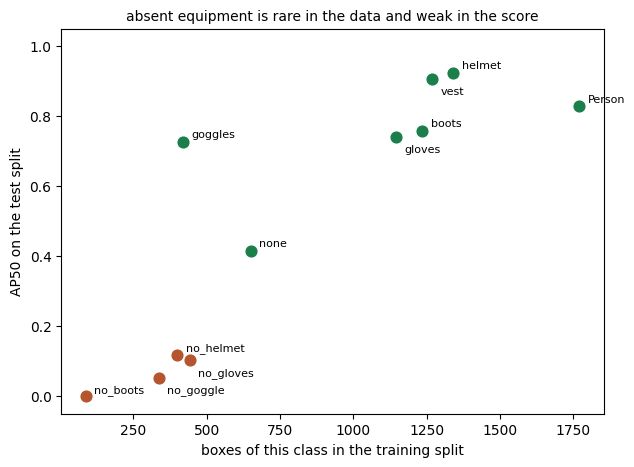

the 4 absent-equipment classes ['no_boots', 'no_gloves', 'no_goggle', 'no_helmet']:
  mean AP50 0.0688 · mean training boxes 317
the other 7 classes ['Person', 'boots', 'gloves', 'goggles', 'helmet', 'none', 'vest']:
  mean AP50 0.7566 · mean training boxes 1119

rarest three classes in training: no_boots 88, no_goggle 337, no_helmet 400

nearly the same number of training boxes, a different kind of class:
    goggles: 419 boxes, AP50 0.7264
  no_helmet: 400 boxes, AP50 0.1181


In [ ]:
# AP50 against training boxes, one labelled point per class.
figure, axis = plt.subplots(figsize=(7, 5))
for name, value in ap50.items():
    rare = name.startswith("no_")
    axis.scatter(counts[name], value, s=60,
                 color=PALETTE[1] if rare else PALETTE[0])
    # A label goes below its point when a higher-scoring neighbour sits close by.
    crowded = any(abs(counts[other] - counts[name]) < 100
                  and 0 < ap50[other] - value < 0.07 for other in ap50)
    axis.annotate(name, (counts[name], value), fontsize=8,
                  textcoords="offset points", xytext=(6, -11 if crowded else 3))
axis.set_xlabel("boxes of this class in the training split")
axis.set_ylabel("AP50 on the test split")
axis.set_ylim(-0.05, 1.05)
axis.set_title("absent equipment is rare in the data and weak in the score",
               fontsize=10)
plt.show()
absent = [name for name in ap50 if name.startswith("no_")]
others = [name for name in ap50 if not name.startswith("no_")]
print(f"the {len(absent)} absent-equipment classes {sorted(absent)}:")
print(f"  mean AP50 {np.mean([ap50[n] for n in absent]):.4f} · "
      f"mean training boxes {np.mean([counts[n] for n in absent]):.0f}")
print(f"the other {len(others)} classes {sorted(others)}:")
print(f"  mean AP50 {np.mean([ap50[n] for n in others]):.4f} · "
      f"mean training boxes {np.mean([counts[n] for n in others]):.0f}")
rarest = sorted(counts.items(), key=lambda kv: kv[1])[:3]
print(f"\nrarest three classes in training: "
      f"{', '.join(f'{n} {c}' for n, c in rarest)}")
# The class that is there whose box count is closest to no_helmet's.
twin = min(others, key=lambda n: abs(counts[n] - counts["no_helmet"]))
print("\nnearly the same number of training boxes, a different kind of class:")
print(f"  {twin:>9}: {counts[twin]} boxes, AP50 {ap50[twin]:.4f}")
print(f"  no_helmet: {counts['no_helmet']} boxes, AP50 {ap50['no_helmet']:.4f}")

Look at the picture before the printout. The four `no_` points sit together
in the bottom left: rare in the training data, and weak on the test split.
Nearly everything else sits high. So rarity is part of the story, but read
the rarest-three line: `no_helmet` is the third rarest class, not the
rarest. And read the last pair: a class that is **there** and a class that
is **absent**, trained on nearly the same number of boxes, with scores far
apart. Rarity alone does not explain that.

The pattern the picture supports is this: **on this dataset, this model is
good at seeing what is there and bad at certifying what is not there.**
That is a reading of one dataset and one training run, not a law about
detectors. One plausible reason: absence has no appearance of its own. A
helmet is a shape; a missing helmet is a head with nothing on it, which
looks like a great many other heads. Being rare in the data on top of that
makes it worse. Section 9 adds one more strand, found by looking at the
photos themselves, and it limits how far this reading travels.

The site camera is bought for the second kind of class. Nothing in this
notebook fixed that, and nothing in this notebook will.

What a practitioner does about it, none of which this notebook tried:
**collect and label more of the rare class**, which is slow and costs
people's time; **weight the rare class up** in the loss, or oversample the
images that contain it; **mine hard negatives**, feeding back the images the
model gets confidently wrong; or **change the task**, so that "person
without helmet" becomes a rule written over two classes the model is good
at, `Person` and `helmet`, instead of one class it has to learn from very
little. That last move needs no new labels, which is why it is worth trying
first. Whichever you try, measure it the way section 7 did.

> 💭 **Reflection:** your own problem has a rare class too, and it is
> probably the one you are paid to catch. Which one is it, and how many
> labelled examples of it do you actually have?

One more check before trusting any of these numbers: is the test split
really held out? The publisher made the split, and nothing promises that two
photos of one scene did not land on both sides of it. The next cell shrinks
every photo to a small greyscale thumbnail, measures how closely each test
photo correlates with every training photo, and scores the model again
without the test photos that have a near-copy in training.

In [ ]:
# Is the test split held out? Every test photo against every training photo.
def thumbnail(path):
    """A 64x64 greyscale thumbnail, mean-centred and scaled to length 1."""
    pixels = np.asarray(Image.open(path).convert("L").resize((64, 64)), dtype=float)
    pixels = pixels.ravel() - pixels.mean()
    return pixels / np.linalg.norm(pixels)


started = time.perf_counter()
test_photos = sorted(TEST_IMAGES.iterdir())
train_photos = sorted((PPE / "images" / "train").iterdir())
# 1. Centred thumbnails of length 1: one matrix product gives every correlation.
similarity = (np.stack([thumbnail(p) for p in test_photos])
              @ np.stack([thumbnail(p) for p in train_photos]).T)
print(f"similarity {similarity.shape}: a row per test photo, a column per training one")
closest = similarity.max(axis=1)
print(f"test photos with a training photo correlating >= 0.90: "
      f"{int((closest >= 0.90).sum())} · >= 0.95: {int((closest >= 0.95).sum())}")
pair = int(closest.argmax())
print(f"closest pair: test {test_photos[pair].name} and train "
      f"{train_photos[int(similarity[pair].argmax())].name}, "
      f"correlation {closest[pair]:.4f}")
# 2. Do those near-copies hold any box of the absent-equipment classes?
near_copies = [p for p, value in zip(test_photos, closest) if value >= 0.90]
ids = [int(line.split()[0]) for p in near_copies
       for line in (TEST_LABELS / f"{p.stem}.txt").read_text().split("\n")
       if line.strip()]
print(f"no_ boxes in those {len(near_copies)} test photos: "
      f"{sum(PPE_NAMES[i].startswith('no_') for i in ids)}")
# 3. Score again without them, on links in out/ to the photos kept: never inside data/.
kept = OUT / "test_without_near_copies"
shutil.rmtree(kept, ignore_errors=True)
for path in test_photos:
    if path in near_copies:
        continue
    label = TEST_LABELS / f"{path.stem}.txt"
    for kind, source in (("images", path), ("labels", label)):
        (kept / kind / "test").mkdir(parents=True, exist_ok=True)
        (kept / kind / "test" / source.name).symlink_to(source.resolve())
spec = yaml.safe_load(PPE_DATA.read_text())
spec["test"] = str(kept / "images" / "test")
(OUT / "kept.yaml").write_text(yaml.safe_dump(spec, sort_keys=False))
kept_metrics = detector.val(data=str(OUT / "kept.yaml"), split="test",
                            device=METRIC_DEVICE, plots=False, verbose=False,
                            project=str(OUT), name="val_test_kept", exist_ok=True)
kept_ap50 = {kept_metrics.names[int(c)]: float(a) for c, a in
             zip(kept_metrics.box.ap_class_index, kept_metrics.box.ap50)}
print(f"test mAP50 without them ({len(test_photos) - len(near_copies)} photos): "
      f"{float(kept_metrics.box.map50):.4f} · with all {len(test_photos)}: {map50:.4f}")
for group, names in (("no_", absent), ("other", others)):
    print(f"  mean AP50 of the {len(names)} {group} classes: "
          f"{np.mean([ap50[n] for n in names]):.4f} with all, "
          f"{np.mean([kept_ap50[n] for n in names]):.4f} without")
print(f"the whole check took {time.perf_counter() - started:.1f} s on {METRIC_DEVICE}")

similarity (141, 1132): a row per test photo, a column per training one
test photos with a training photo correlating >= 0.90: 26 · >= 0.95: 11
closest pair: test image834.jpg and train image833.jpg, correlation 0.9991
no_ boxes in those 26 test photos: 0
test mAP50 without them (115 photos): 0.4810 · with all 141: 0.5065
  mean AP50 of the 4 no_ classes: 0.0688 with all, 0.0677 without
  mean AP50 of the 7 other classes: 0.7566 with all, 0.7172 without
the whole check took 12.0 s on cuda


Frames a moment apart from one scene landed on both sides of the
publisher's split: the closest pair above are numbered one apart, and none
of the near-copies holds a `no_` box. So the leak inflates the classes for
equipment that is there, leaves the `no_` classes almost exactly where they
were, and is exactly the leak the take-home warns about.

## 9. Threshold theatre

Every detector has a confidence threshold, and most demos quietly leave it
at the default. Ultralytics' default is 0.25, which is what sections 2, 3
and 5 used. The next cells run the model
once at a very low threshold, keep every candidate, and then count what each
threshold would have done to the `no_helmet` class on the test split.

Three counts per threshold, all at IoU 0.5:
**found** (bare heads correctly boxed), **missed** (bare heads in the labels
that no detection claimed), and **false alarms per image**.

> 🔮 **Predict first:** at the default threshold of 0.25, how many of the 40
> bare heads in the test split does this model catch?

In [ ]:
# One pass over every test image at conf 0.05, then sweep the thresholds in numpy.
NO_HELMET = [i for i, n in detector.names.items() if n == "no_helmet"][0]
test_files = sorted(TEST_IMAGES.iterdir())
started = time.perf_counter()
per_image = []
for chunk in range(0, len(test_files), 16):
    batch = test_files[chunk:chunk + 16]
    for path, result in zip(batch, detector.predict([str(p) for p in batch],
                                                    device=METRIC_DEVICE, conf=0.05,
                                                    verbose=False)):
        shot_h, shot_w = result.orig_shape
        keep = (result.boxes.cls == NO_HELMET).cpu().numpy()
        per_image.append((ground_truth(path.stem, NO_HELMET, shot_w, shot_h),
                          result.boxes.xyxy.cpu().numpy()[keep],
                          result.boxes.conf.cpu().numpy()[keep]))
total_truth = sum(len(gt) for gt, _, _ in per_image)
print(f"{len(test_files)} test images in {time.perf_counter() - started:.1f} s "
      f"on {METRIC_DEVICE}")
print(f"no_helmet boxes in the test labels: {total_truth} · "
      f"candidates at conf >= 0.05: {sum(len(c) for _, _, c in per_image)}")

141 test images in 1.9 s on cuda
no_helmet boxes in the test labels: 40 · candidates at conf >= 0.05: 184


In [ ]:
# The sweep. Same greedy matching as section 6, run once per threshold.
THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.70, 0.90]
sweep = []
for threshold in THRESHOLDS:
    found = false_alarms = 0
    for gt_boxes, boxes, confs in per_image:
        claimed = set()
        # 1. Most confident first, so the best detection claims a box first.
        for index in np.argsort(-confs):
            # 2. Everything below the threshold never leaves the model.
            if confs[index] < threshold:
                continue
            # 3. A hit needs IoU >= 0.5 with a bare head nobody has claimed yet.
            overlaps = [iou(boxes[index], gt) for gt in gt_boxes]
            best = int(np.argmax(overlaps)) if overlaps else -1
            if best >= 0 and overlaps[best] >= 0.5 and best not in claimed:
                claimed.add(best)
                found += 1
            else:
                # 4. Everything else is a guard sent to look at nothing.
                false_alarms += 1
    sweep.append((threshold, found, total_truth - found, false_alarms,
                  false_alarms / len(per_image)))

print(f"{'conf':>6} {'found':>7} {'missed':>7} {'false alarms':>13} "
      f"{'per image':>10} {'recall':>8}")
for threshold, found, missed, false_alarms, per_img in sweep:
    print(f"{threshold:>6.2f} {found:>7} {missed:>7} {false_alarms:>13} "
          f"{per_img:>10.2f} {found / total_truth:>8.3f}")

  conf   found  missed  false alarms  per image   recall
  0.05      19      21           165       1.17    0.475
  0.10      12      28            61       0.43    0.300
  0.15       5      35            24       0.17    0.125
  0.20       4      36            10       0.07    0.100
  0.25       0      40             4       0.03    0.000
  0.30       0      40             4       0.03    0.000
  0.40       0      40             1       0.01    0.000
  0.50       0      40             1       0.01    0.000
  0.70       0      40             0       0.00    0.000
  0.90       0      40             0       0.00    0.000


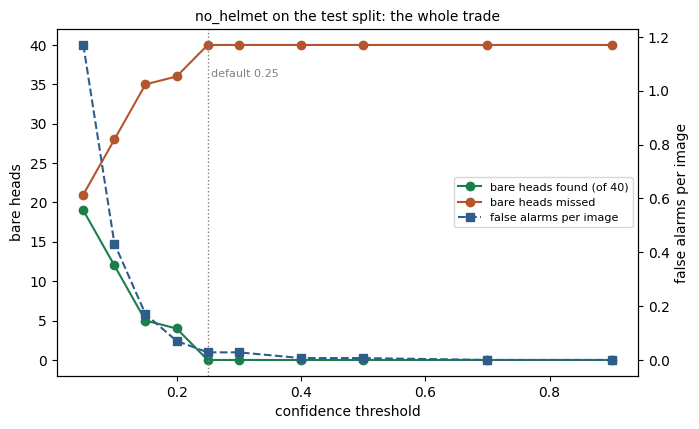

at the default 0.25: 0 of 40 bare heads found, 40 missed, 0.03 false alarms per image
at the loosest 0.05: 19 of 40 bare heads found, 21 missed, 1.17 false alarms per image


In [ ]:
# The same table as a picture: what you gain and what you pay, threshold by threshold.
grid_conf = [row[0] for row in sweep]
figure, left = plt.subplots(figsize=(7.5, 4.5))
found_line, = left.plot(grid_conf, [row[1] for row in sweep], "o-",
                        color=PALETTE[0],
                        label=f"bare heads found (of {total_truth})")
missed_line, = left.plot(grid_conf, [row[2] for row in sweep], "o-",
                         color=PALETTE[1], label="bare heads missed")
left.set_xlabel("confidence threshold")
left.set_ylabel("bare heads")
right = left.twinx()
alarm_line, = right.plot(grid_conf, [row[4] for row in sweep], "s--",
                         color=PALETTE[2], label="false alarms per image")
right.set_ylabel("false alarms per image")
left.axvline(0.25, color="grey", ls=":", lw=1)
left.text(0.255, total_truth * 0.9, "default 0.25", fontsize=8, color="grey")
handles = [found_line, missed_line, alarm_line]
left.legend(handles, [line.get_label() for line in handles], fontsize=8,
            loc="center right")
left.set_title("no_helmet on the test split: the whole trade", fontsize=10)
plt.show()
default = [row for row in sweep if row[0] == 0.25][0]
loosest = sweep[0]
print(f"at the default 0.25: {default[1]} of {total_truth} bare heads found, "
      f"{default[2]} missed, {default[4]:.2f} false alarms per image")
print(f"at the loosest 0.05: {loosest[1]} of {total_truth} bare heads found, "
      f"{loosest[2]} missed, {loosest[4]:.2f} false alarms per image")

Now pick one, out loud, before reading on.

Here is the frame to pick it in, and it is the only frame that matters.
A **missed** bare head is a person standing on a live site with nothing on
their head, and the camera that was installed to see it did not. A **false
alarm** is someone walking to a bay to look at a head that already has a
helmet on it. Those are the two units. This notebook will not price them in
rupees, because the price depends on your site, your staffing and what the
regulator does when it goes wrong. Count them, put both counts in front of
the person who owns the risk, and let them choose.

Read the loosest row again before you do. Even with the threshold dropped as
far as we looked, most of the bare heads are still missed, and the false
alarms have arrived anyway. **A threshold cannot recover a class the model
never learned.** That is a data problem, and it is section 8's problem.

There is one more thing to check before anyone acts on those counts, and it
is the most important habit in this notebook: look at the photos behind the
number.

> 🔮 **Predict first:** the test split holds the bare heads we just counted.
> This is a construction-site dataset. What do you expect those photos to
> show?

train: no_helmet boxes in photos that also label worn equipment 112 · in photos that label none 288
test: no_helmet boxes in photos that also label worn equipment 17 · in photos that label none 23
the test split's 40 no_helmet boxes sit in 24 photos:
showing 22 of the 24: image1256.jpg and image1264.jpg are left out because they show firearms


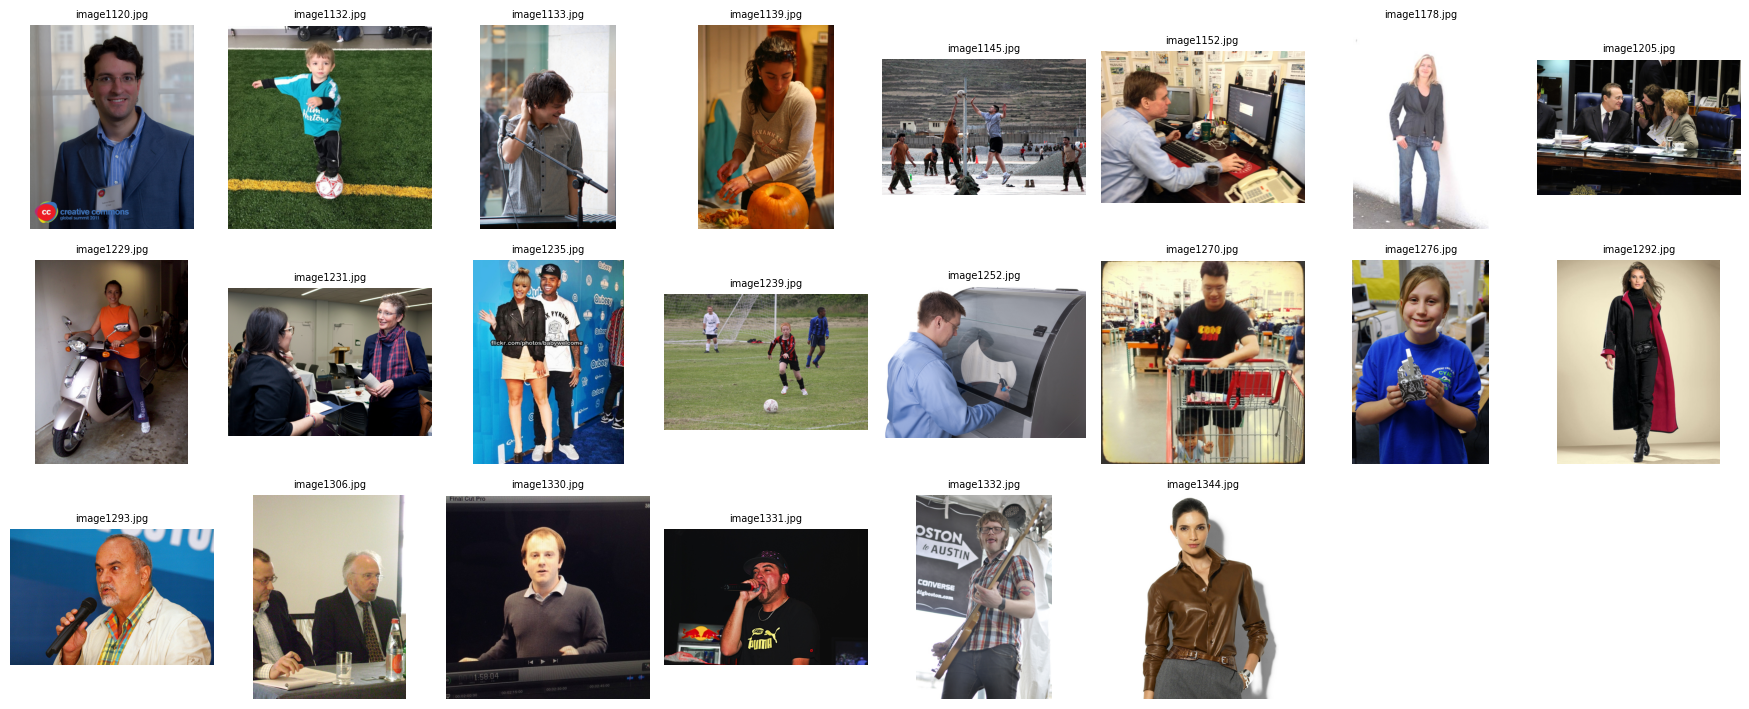

In [ ]:
# The photos that hold the no_helmet labels, and a crude check of where they come from.
WORN = {i for i, n in PPE_NAMES.items()
        if n in ("helmet", "gloves", "vest", "boots", "goggles")}
bare_photos = {}
for split in ("train", "test"):
    images = {path.stem: path for path in (PPE / "images" / split).iterdir()}
    with_ppe = without_ppe = 0
    for label_file in sorted((PPE / "labels" / split).glob("*.txt")):
        ids = [int(line.split()[0]) for line in label_file.read_text().split("\n")
               if line.strip()]
        # 1. Only photos that exist and hold at least one bare head count.
        if label_file.stem not in images or NO_HELMET not in ids:
            continue
        # 2. The crude check: is any worn equipment labelled in the same photo?
        if WORN & set(ids):
            with_ppe += ids.count(NO_HELMET)
        else:
            without_ppe += ids.count(NO_HELMET)
        if split == "test":
            bare_photos[label_file.stem] = images[label_file.stem]
    print(f"{split}: no_helmet boxes in photos that also label worn equipment "
          f"{with_ppe} · in photos that label none {without_ppe}")
print(f"the test split's {total_truth} no_helmet boxes sit in "
      f"{len(bare_photos)} photos:")
# Two of them show firearms, so they stay off the screen; every count above keeps them.
NOT_SHOWN = {"image1256.jpg", "image1264.jpg"}
shown = [path for path in sorted(bare_photos.values()) if path.name not in NOT_SHOWN]
print(f"showing {len(shown)} of the {len(bare_photos)}: "
      f"{' and '.join(sorted(NOT_SHOWN))} are left out because they show firearms")
columns = 8
grid_rows = -(-len(shown) // columns)  # division rounded up
figure, axes = plt.subplots(grid_rows, columns,
                            figsize=(2.2 * columns, 2.4 * grid_rows))
for axis in axes.flat:
    axis.axis("off")
for axis, path in zip(axes.flat, shown):
    axis.imshow(np.asarray(Image.open(path).convert("RGB")))
    axis.set_title(path.name, fontsize=7)
plt.tight_layout()
plt.show()

Look at them before reading on.

In the copy of the dataset this notebook was built on, **not one of these
photos is a building site.** They are portraits, offices, sports pitches, a
shop, a stage. The crude check printed above is generous (a photo passes it
if any worn equipment is labelled anywhere in it, and several that pass are
still not sites), and even so, most of the training split's bare heads come
from photos with no worn equipment labelled at all.

So the sweep above measured how well the model finds bare heads in everyday
photographs, not on a site. The units were right: found, missed, false
alarms. The photos are not the ones the decision is about. **Before you
choose a threshold for a real camera, you need test photos from that
camera.** No number in this notebook can stand in for them. It also adds a
strand to section 8's story: the class the camera is bought for was taught,
and is tested, mostly on photos that are not from sites. Whether that is why
it scores so badly, this notebook has not measured.

One caution before anyone quotes these counts at each other: every
`no_helmet` number in this notebook, AP50 included, rests on the bare heads
in the test split, and the sweep printed how few of those there are. On a
base that small, a small difference between two models on this one class is
noise, not an improvement.

## 10. The same three lines, a different world

Nothing in section 7 was about construction. Point the same call at a
different dataset yaml and the same three lines train a different detector.
Here it is on **brain-tumor** (Ultralytics, AGPL-3.0) [S5]: medical images
"from MRI and CT scans", in the publisher's words, with tumour boxes in two
classes, which the publisher describes as "negative (no tumor)" and
"positive (tumor present)" [S5]. The cell prints the size of each split
before it starts. As in section 7, it loads a checkpoint trained before the
session with these same lines, and prints how long that took: again this Mac's
`mps` wall clock, and again untimed on a Colab GPU.

In [ ]:
# The identical branch, the identical three lines, a different yaml.
BRAIN = DATA / "brain-tumor"
brain_splits = {split: len(list((BRAIN / "images" / split).iterdir()))
                for split in ("train", "val")}
print(f"brain-tumor images (MRI and CT): {brain_splits}")
started = time.perf_counter()
if TRAIN_LIVE:
    brain = YOLO(str(WEIGHTS))
    brain.train(data=str(BRAIN_DATA), epochs=EPOCHS, imgsz=640, batch=16,
                device=DEVICE, seed=0, deterministic=True, workers=2,
                project=str(OUT), name="brain", exist_ok=True, plots=False)
    brain = YOLO(str(brain.trainer.best))
    print(f"trained here: {EPOCHS} epochs on {DEVICE} in "
          f"{time.perf_counter() - started:.0f} s")
else:
    brain = YOLO(str(ASSETS / "brain_yolo26n_10ep.pt"))
    print(f"TRAIN_LIVE is off: loaded the shipped checkpoint "
          f"{ASSETS / 'brain_yolo26n_10ep.pt'} in "
          f"{time.perf_counter() - started:.1f} s")
    record = json.loads((ASSETS / "brain_yolo26n_10ep.json").read_text())
    print(f"that training took {record['train_seconds']:.0f} s on "
          f"{record['trained_on']}, before the session")
started = time.perf_counter()
brain_metrics = brain.val(data=str(BRAIN_DATA), split="val", device=METRIC_DEVICE,
                          plots=False, verbose=False, project=str(OUT),
                          name="val_brain", exist_ok=True)
brain_map50 = float(brain_metrics.box.map50)
brain_map50_95 = float(brain_metrics.box.map)
print(f"validated on {METRIC_DEVICE} in {time.perf_counter() - started:.1f} s")
print(f"brain-tumor val mAP50 {brain_map50:.4f} · "
      f"val mAP50-95 {brain_map50_95:.4f}")
print(f"{'class':>10} {'AP50':>8}")
for class_index, value in zip(brain_metrics.box.ap_class_index,
                              brain_metrics.box.ap50):
    print(f"{brain_metrics.names[int(class_index)]:>10} {float(value):>8.4f}")

brain-tumor images (MRI and CT): {'train': 893, 'val': 223}
TRAIN_LIVE is off: loaded the shipped checkpoint brain_yolo26n_10ep.pt in 0.1 s
that training took 1204 s on mps, before the session
validated on cuda in 2.8 s
brain-tumor val mAP50 0.5568 · val mAP50-95 0.4062
     class     AP50
  negative   0.6284
  positive   0.4852


val_1 (1).jpg: labelled positive
val_1 (10).jpg: labelled negative
val_1 (100).jpg: labelled positive
val_1 (101).jpg: labelled negative


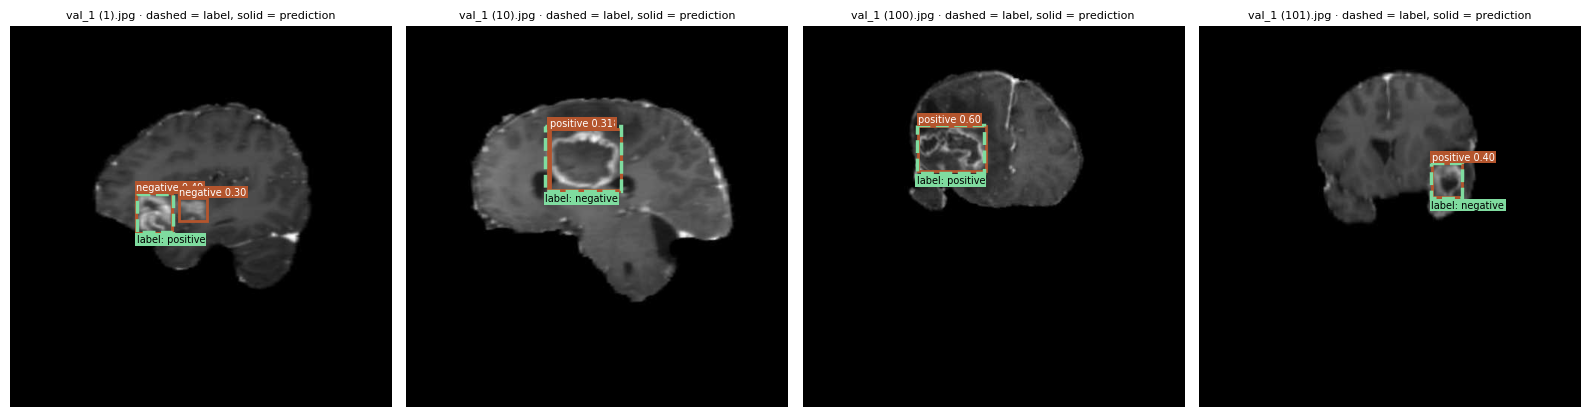

In [ ]:
# Four validation slices: the model's boxes in one colour, the labels in another.
BRAIN_VAL = BRAIN / "images" / "val"
BRAIN_LABELS = BRAIN / "labels" / "val"
slices = sorted(BRAIN_VAL.iterdir())[:4]
slice_results = brain.predict([str(p) for p in slices], device=METRIC_DEVICE,
                              conf=0.25, verbose=False)
figure, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for axis, path, result in zip(axes, slices, slice_results):
    slice_h, slice_w = result.orig_shape
    axis.imshow(np.asarray(Image.open(path).convert("RGB")))
    labelled = []
    for line in (BRAIN_LABELS / f"{path.stem}.txt").read_text().strip().split("\n"):
        parts = line.split()
        if not parts:
            continue
        centre_x, centre_y, box_w, box_h = (float(v) for v in parts[1:5])
        labelled.append(brain.names[int(parts[0])])
        # zorder 3 keeps the label's dashed box visible on top of a prediction.
        axis.add_patch(Rectangle(((centre_x - box_w / 2) * slice_w,
                                  (centre_y - box_h / 2) * slice_h),
                                 box_w * slice_w, box_h * slice_h, fill=False,
                                 lw=2.5, edgecolor="#7fdc9f", ls="--", zorder=3))
        # The label's own class, under its box: compare it with what the slice shows.
        axis.text((centre_x - box_w / 2) * slice_w,
                  (centre_y + box_h / 2) * slice_h + 14, f"label: {labelled[-1]}",
                  fontsize=7, bbox={"facecolor": "#7fdc9f", "pad": 1,
                                    "edgecolor": "none"})
    print(f"{path.name}: labelled {', '.join(labelled)}")
    for box, cls, conf in zip(result.boxes.xyxy.cpu().numpy(),
                              result.boxes.cls.cpu().numpy(),
                              result.boxes.conf.cpu().numpy()):
        axis.add_patch(Rectangle((box[0], box[1]), box[2] - box[0],
                                 box[3] - box[1], fill=False, lw=2,
                                 edgecolor=PALETTE[1]))
        axis.text(box[0], box[1] - 4, f"{brain.names[int(cls)]} {conf:.2f}",
                  fontsize=7, color="white",
                  bbox={"facecolor": PALETTE[1], "pad": 1, "edgecolor": "none"})
    axis.set_title(f"{path.name} · dashed = label, solid = prediction", fontsize=8)
    axis.axis("off")
plt.tight_layout()
plt.show()

**Read this before you read the pictures.**

* This is a **small teaching dataset**, redistributed by a library. It comes
  with no clinical provenance, and we did not verify that its train and
  validation splits separate patients rather than slices. If two slices of
  the same head sit on both sides of the split, the validation number above
  is optimistic and we cannot say by how much.
* **The labels contradict the publisher's own class definitions.** The
  publisher describes the classes as "negative (no tumor)" and "positive
  (tumor present)" [S5], yet the labels are boxes, and some `negative`
  boxes sit on visible lesions. In the figure above, `val_1 (10).jpg` and
  `val_1 (101).jpg` carry a `negative` box around a visible lesion, as the
  printed labels confirm. A model trained on these labels learns that
  contradiction, and its per-class numbers cannot be read as "tumour"
  against "no tumour".
* A box on a tumour is **not a diagnosis**. Nothing computed in this section
  says anything about any patient, and none of it should be repeated as if
  it did.
* Cleared products in medical imaging do exist, and they are held to a
  different standard altogether: a regulator's review of a formal study,
  with measured sensitivity and specificity. The closing slides carry two
  such FDA records, a diabetic-retinopathy screening system and a stroke
  triage device, each with its own numbers. A notebook is not that.
* The transferable lesson is the honest one: **the same twenty lines that
  trained a detector on site photos trained one on brain scans.** The model
  is the commodity. What is not commodity is the licence you ship under,
  where the data came from, what its labels mean, whether the split is
  honest, and what happens when the thing is wrong. That is the work.

> 💭 **Reflection:** what would you need to see before you let a number from
> a model like this one change a decision about a person?

In [ ]:
# Everything this notebook measured, in one table.
best_class = max(ap50, key=ap50.get)
verdict = [
    ("YOLO26n, COCO-pretrained", "site photos", "no PPE class exists", ""),
    ("YOLO26n, COCO-pretrained", f"{len(FOUR)} test photos, person",
     f"AP50 {ap50_person:.4f}", f"{n_truth} labelled people"),
    (f"YOLO26n fine-tuned, {EPOCHS} epochs", "construction-ppe test",
     f"mAP50 {map50:.4f}", f"mAP50-95 {map50_95:.4f}"),
    ("  its best class", f"construction-ppe test, {best_class}",
     f"AP50 {ap50[best_class]:.4f}", f"{counts[best_class]} train boxes"),
    # Its photos are not building sites (section 9), and this is one training run.
    ("  no_helmet, non-site photos", "construction-ppe test, no_helmet",
     f"AP50 {ap50['no_helmet']:.4f}", f"{total_truth} test boxes, one seed"),
    ("  at the default threshold 0.25", "construction-ppe test, no_helmet",
     f"{default[1]} of {total_truth} found", f"{default[4]:.2f} false/image"),
    (f"YOLO26n fine-tuned, {EPOCHS} epochs", "brain-tumor val",
     f"mAP50 {brain_map50:.4f}", f"mAP50-95 {brain_map50_95:.4f}"),
]
widths = [max(len(str(row[i])) for row in verdict) for i in range(4)]
print(f"every number below was measured on {METRIC_DEVICE} in this session\n")
for row in verdict:
    print("  ".join(str(cell).ljust(widths[i]) for i, cell in enumerate(row)))

every number below was measured on cuda in this session

YOLO26n, COCO-pretrained         site photos                       no PPE class exists                         
YOLO26n, COCO-pretrained         4 test photos, person             AP50 0.8292          11 labelled people     
YOLO26n fine-tuned, 10 epochs    construction-ppe test             mAP50 0.5065         mAP50-95 0.2507        
  its best class                 construction-ppe test, helmet     AP50 0.9234          1341 train boxes       
  no_helmet, non-site photos     construction-ppe test, no_helmet  AP50 0.1181          40 test boxes, one seed
  at the default threshold 0.25  construction-ppe test, no_helmet  0 of 40 found        0.03 false/image       
YOLO26n fine-tuned, 10 epochs    brain-tumor val                   mAP50 0.5568         mAP50-95 0.4062        


In [ ]:
!pip install -q ultralytics
from ultralytics import YOLO

model = YOLO("yolo26n.pt")
r = model.predict("https://ultralytics.com/images/bus.jpg", save=True)
print(r[0].boxes.cls, r[0].boxes.conf)


tensor([5., 0., 0., 0., 0.], device='cuda:0') tensor([0.8806, 0.8720, 0.8608, 0.8462, 0.6562], device='cuda:0')


## Summary

1. **A detection is four numbers, a class and a confidence.** Everything
   else in a detector is machinery for producing them and cleaning them up.
2. **IoU and NMS are a few lines each.** Our own NMS returned the same count
   as the library's on a real photo. YOLO26 can skip NMS entirely with
   `nms=False`, but its default prediction path still runs it [S2].
3. **AP is a walk down a sorted list.** Sort by confidence, mark TP or FP at
   IoU 0.5, accumulate precision and recall, take the area. mAP50 averages
   that over classes; mAP50-95 averages it again over ten IoU thresholds.
4. **Fine-tuning is three lines**, and the same three lines moved from a
   construction site to brain MRI and CT with only the dataset yaml changed.
5. **The headline hides the classes for absent equipment.** On this dataset
   all four scored badly. They are rare, but a class that is there, trained
   on nearly as few boxes as `no_helmet`, scored far higher. Read that as
   this dataset, not as detectors in general: the `no_helmet` photos are not
   building sites, so the weakness was measured on everyday photos and is
   confounded with that, and it is one seed on 40 test boxes.
6. **A threshold trades two named mistakes**, missed bare heads against
   false alarms per image, and it cannot rescue a class the model never
   learned. On a class with this few test boxes, small differences are noise.
7. **Look at the photos behind the number.** The test split's bare heads are
   not on building sites. A threshold for a real camera needs test photos
   from that camera.

## Take it further

Each of these is judged on two numbers against section 7's: test mAP50 and test
`no_helmet` AP50. Choose among your attempts on **val**, score **test** once, and
remember `no_helmet` rests on 40 test boxes: a narrow win there is not a win.

1. **A bigger backbone.** Swap `yolo26n.pt` for `yolo26s.pt` and rerun
   section 7 unchanged. Report test mAP50 and `no_helmet` AP50 against the
   baseline, and the seconds per epoch you paid for the difference.
2. **More epochs.** Run the same recipe for 30 epochs instead of 10 and plot
   both numbers against epoch count. Decide, with the curve in front of you,
   whether the rare classes improved at the same rate as the common ones.
3. **An imbalance fix.** Build a training subset in which every image
   containing a `no_` class appears three times, retrain for the same 10
   epochs, and measure what it did to `no_helmet` and what it cost the other
   ten classes. Then try the rule from section 8 instead: flag a `Person` box
   with no `helmet` box near its top, and score that on the same test split.

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ZggZOH7soe526ci91Yfo")
project = rf.workspace("muhammad-sultan-qslpu").project("annotating_dataset-iepnb")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 361.2/361.2 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 122.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to annotating_dataset-1 in yolov8:: 100%|██████████| 8510/8510 [00:01<00:00, 4868.28it/s]


In [ ]:
import os, glob
print(dataset.location)                       # download hone ki jagah
print(os.listdir(dataset.location))
for split in ["train", "valid", "test"]:
    n = len(glob.glob(f"{dataset.location}/{split}/images/*"))
    print(split, "images:", n)
print(open(f"{dataset.location}/data.yaml").read())

/content/annotating_dataset-1
['valid', 'README.roboflow.txt', 'data.yaml', 'test', 'train']
train images: 2981
valid images: 640
test images: 632
names:
- human
- object
- seat_area
nc: 3
roboflow:
  license: CC BY 4.0
  project: annotating_dataset-iepnb
  url: https://app.roboflow.com/muhammad-sultan-qslpu/annotating_dataset-iepnb/1
  version: 1
  workspace: muhammad-sultan-qslpu
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
import yaml, glob
from collections import Counter

loc = "/content/annotating_dataset-1"
spec = yaml.safe_load(open(f"{loc}/data.yaml"))
names = spec["names"]

fixed = {
    "path": loc,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {i: n for i, n in enumerate(names)},
}
yaml.safe_dump(fixed, open("/content/data_fixed.yaml", "w"))
print(open("/content/data_fixed.yaml").read())

for split in ["train", "valid", "test"]:
    c = Counter()
    for f in glob.glob(f"{loc}/{split}/labels/*.txt"):
        for line in open(f):
            if line.strip():
                c[int(line.split()[0])] += 1
    print(split, {names[k]: v for k, v in sorted(c.items())})

names:
  0: human
  1: object
  2: seat_area
path: /content/annotating_dataset-1
test: test/images
train: train/images
val: valid/images

train {'human': 10666, 'object': 8525, 'seat_area': 26473}
valid {'human': 3111, 'object': 1922, 'seat_area': 5120}
test {'human': 2649, 'object': 2205, 'seat_area': 5056}


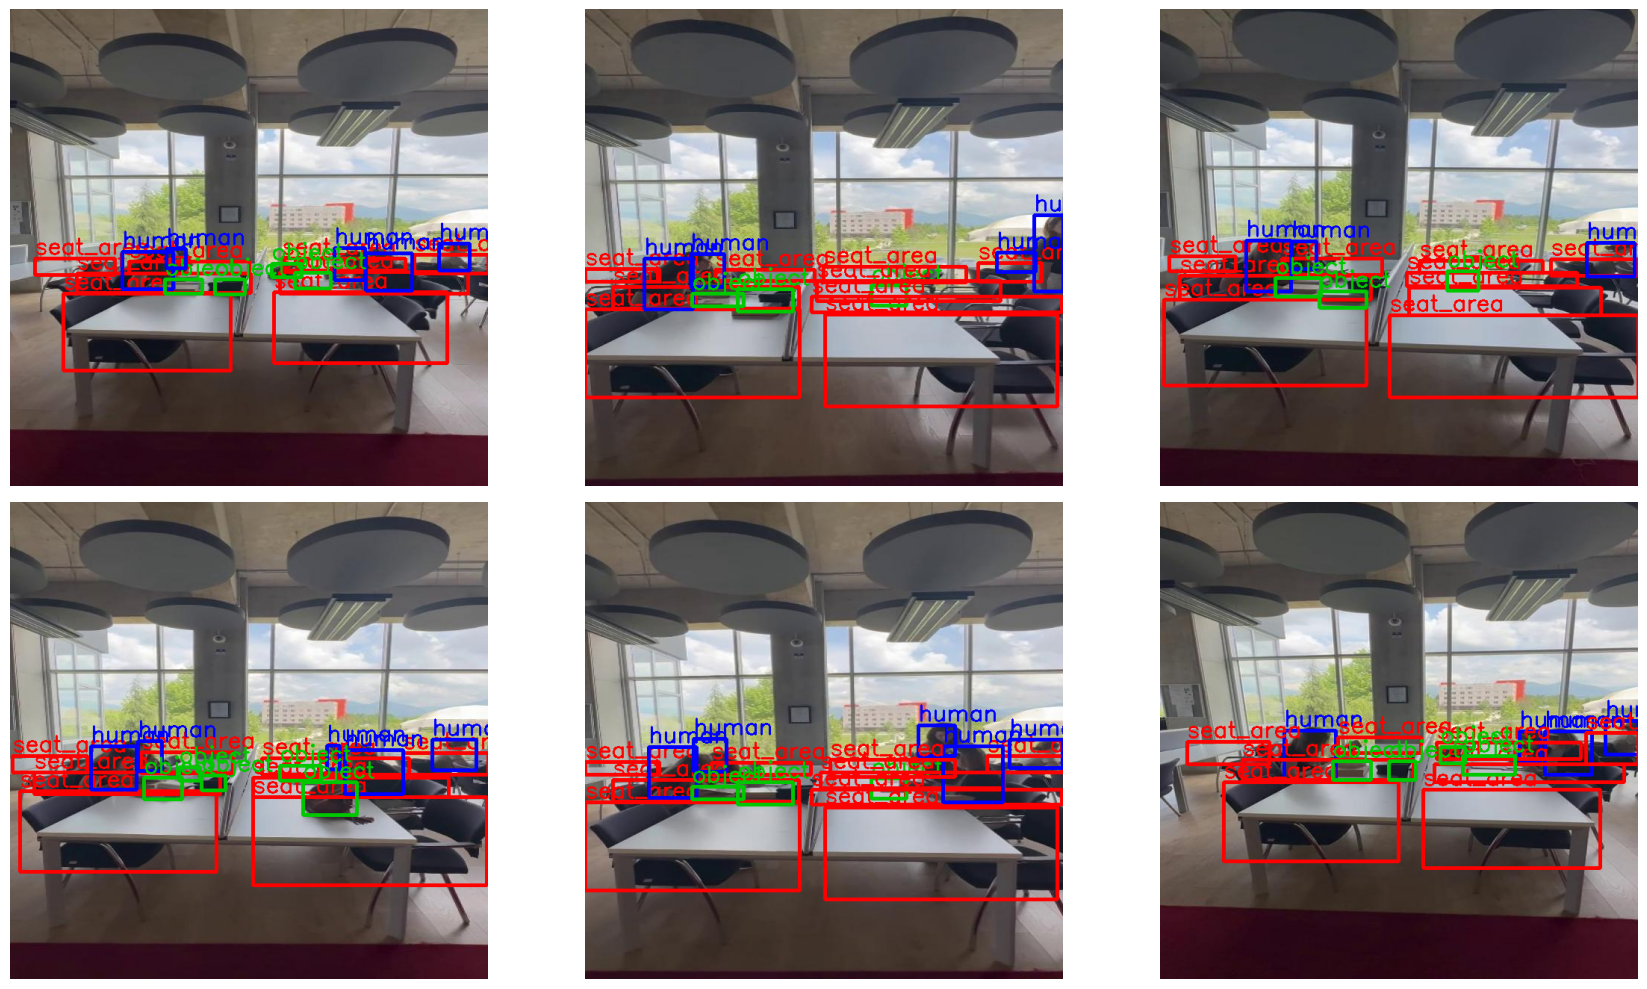

In [ ]:
import random, cv2
import matplotlib.pyplot as plt

imgs = glob.glob(f"{loc}/train/images/*")
random.seed(1)
colors = {0: (0,0,255), 1: (0,200,0), 2: (255,0,0)}   # human=laal, object=hara, seat_area=neela (RGB)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, p in zip(axes.ravel(), random.sample(imgs, 6)):
    im = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    h, w = im.shape[:2]
    lab = p.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"
    for line in open(lab):
        if not line.strip(): continue
        c, cx, cy, bw, bh = line.split()[:5]
        c = int(c); cx, cy, bw, bh = (float(v) for v in (cx, cy, bw, bh))
        x1, y1 = int((cx-bw/2)*w), int((cy-bh/2)*h)
        x2, y2 = int((cx+bw/2)*w), int((cy+bh/2)*h)
        cv2.rectangle(im, (x1,y1), (x2,y2), colors[c], 3)
        cv2.putText(im, names[c], (x1, max(y1-6, 12)), cv2.FONT_HERSHEY_SIMPLEX, 1.0, colors[c], 2)
    ax.imshow(im); ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np, glob
from PIL import Image

loc = "/content/annotating_dataset-1"

def thumb(p):
    a = np.asarray(Image.open(p).convert("L").resize((64, 64)), dtype=float).ravel()
    a = a - a.mean()
    return a / np.linalg.norm(a)

tr = sorted(glob.glob(f"{loc}/train/images/*"))
te = sorted(glob.glob(f"{loc}/test/images/*"))
sim = np.stack([thumb(p) for p in te]) @ np.stack([thumb(p) for p in tr]).T
best = sim.max(axis=1)
for t in (0.90, 0.95, 0.99):
    print(f"test images with a train image correlating >= {t}: {(best >= t).sum()} of {len(te)}")
print("median best correlation:", np.median(best))

test images with a train image correlating >= 0.9: 310 of 632
test images with a train image correlating >= 0.95: 105 of 632
test images with a train image correlating >= 0.99: 67 of 632
median best correlation: 0.8994602969997485


In [ ]:
import os, shutil

loc = "/content/annotating_dataset-1"
ci, cl = f"{loc}/test_clean/images", f"{loc}/test_clean/labels"
os.makedirs(ci, exist_ok=True); os.makedirs(cl, exist_ok=True)

kept = 0
for p, b in zip(te, best):          # te, best pichhle cell se
    if b < 0.95:
        lab = p.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"
        shutil.copy(p, ci); shutil.copy(lab, cl); kept += 1
print("clean test images:", kept, "of", len(te))

import yaml
spec = yaml.safe_load(open("/content/data_fixed.yaml"))
spec["test"] = "test_clean/images"
yaml.safe_dump(spec, open("/content/data_clean.yaml", "w"))


clean test images: 527 of 632


In [ ]:
from ultralytics import YOLO
base = YOLO("yolo26n.pt")
b = base.val(data="/content/data_fixed.yaml", split="test", classes=[0],
             device=0, plots=False, verbose=False)
print("BASELINE human AP50:", b.box.ap50[0] if len(b.box.ap50) else "n/a")
print("BASELINE mAP50 (3 classes, baqi 0):", b.box.map50)

BASELINE human AP50: 0.12331357907144963
BASELINE mAP50 (3 classes, baqi 0): 0.12331357907144963


In [ ]:
import torch; print(torch.cuda.is_available())   # True aana chahiye


True


## References

* [S1] Ultralytics YOLO, AGPL-3.0: https://github.com/ultralytics/ultralytics
* [S2] YOLO26 model documentation: https://docs.ultralytics.com/models/yolo26/
* [S3] Ultralytics licensing, AGPL-3.0 and Enterprise: https://www.ultralytics.com/license
* [S4] The construction-ppe dataset: https://docs.ultralytics.com/datasets/detect/construction-ppe/
* [S5] The brain-tumor dataset: https://docs.ultralytics.com/datasets/detect/brain-tumor/
* [S6] COCO detection evaluation, which makes no distinction between AP and mAP: https://cocodataset.org/#detection-eval
* [S18] RF-DETR, Apache-2.0, the permissive alternative: https://github.com/roboflow/rf-detr
* [S33] Ultralytics issue 24399, validation metrics on mps: https://github.com/ultralytics/ultralytics/issues/24399

In [ ]:
!ls /content


annotating_dataset-1				     out
annotating_dataset.v1-dataset_object_itu.yolov8.zip  ppe_yolo26n_10ep.json
brain_yolo26n_10ep.json				     ppe_yolo26n_10ep.pt
brain_yolo26n_10ep.pt				     runs
bus.jpg						     sample_data
data_clean.yaml					     weights
data_fixed.yaml					     yolo26n.pt
datasets


In [ ]:
import torch; print(torch.cuda.is_available())

from ultralytics import YOLO
model = YOLO("yolo26n.pt")
model.train(data="/content/data_fixed.yaml", epochs=10, imgsz=640, batch=16,
            seed=0, device=0, workers=2, cache=False,
            project="/content/runs", name="seat10", exist_ok=True, plots=False)

True
New https://pypi.org/project/ultralytics/8.4.174 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7db652753980>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
from ultralytics import YOLO
import json

best = YOLO("/content/runs/seat10/weights/best.pt")
out = {"baseline_pretrained_human_AP50_on_test": 0.1233}

for tag, yml, split in [("valid",      "/content/data_fixed.yaml", "val"),
                        ("test_full",  "/content/data_fixed.yaml", "test"),
                        ("test_clean", "/content/data_clean.yaml", "test")]:
    r = best.val(data=yml, split=split, device=0, plots=True, verbose=False,
                 project="/content/runs/eval", name=tag, exist_ok=True)
    out[tag] = {
        "mAP50": round(float(r.box.map50), 4),
        "mAP50-95": round(float(r.box.map), 4),
        "precision": round(float(r.box.mp), 4),
        "recall": round(float(r.box.mr), 4),
        "per_class_AP50": {r.names[int(c)]: round(float(a), 4)
                           for c, a in zip(r.box.ap_class_index, r.box.ap50)},
        "per_class_AP50-95": {r.names[int(c)]: round(float(r.box.maps[int(c)]), 4)
                              for c in r.box.ap_class_index},
    }

json.dump(out, open("/content/runs/metrics_summary.json", "w"), indent=1)
print(json.dumps(out, indent=1))

Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 715.2±217.8 MB/s, size: 39.5 KB)
val: Scanning /content/annotating_dataset-1/valid/labels.cache... 640 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 640/640 134.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 2.1it/s 19.3s
                   all        640      10153      0.595      0.568       0.52      0.177
Speed: 3.2ms preprocess, 6.5ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to /content/runs/eval/valid
Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 191.6±172.6 MB/s, size: 39.8 KB)
val: Scanning

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ZggZOH7soe526ci91Yfo")
project = rf.workspace("muhammad-sultan-qslpu").project("annotating_dataset-iepnb")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 361.2/361.2 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to annotating_dataset-1 in yolov8:: 100%|██████████| 8510/8510 [00:02<00:00, 4249.73it/s]


In [4]:
import yaml
loc = "/content/annotating_dataset-1"
names = yaml.safe_load(open(f"{loc}/data.yaml"))["names"]
fixed = {"path": loc, "train": "train/images", "val": "valid/images",
         "test": "test/images", "names": {i: n for i, n in enumerate(names)}}
yaml.safe_dump(fixed, open("/content/data_fixed.yaml", "w"))
print(open("/content/data_fixed.yaml").read())

names:
  0: human
  1: object
  2: seat_area
path: /content/annotating_dataset-1
test: test/images
train: train/images
val: valid/images



In [5]:
import numpy as np, glob, os, shutil
from PIL import Image

def thumb(p):
    a = np.asarray(Image.open(p).convert("L").resize((64, 64)), dtype=float).ravel()
    a = a - a.mean()
    return a / np.linalg.norm(a)

tr = sorted(glob.glob(f"{loc}/train/images/*"))
te = sorted(glob.glob(f"{loc}/test/images/*"))
best = (np.stack([thumb(p) for p in te]) @ np.stack([thumb(p) for p in tr]).T).max(axis=1)

ci, cl = f"{loc}/test_clean/images", f"{loc}/test_clean/labels"
os.makedirs(ci, exist_ok=True); os.makedirs(cl, exist_ok=True)
kept = 0
for p, b in zip(te, best):
    if b < 0.95:
        lab = p.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"
        shutil.copy(p, ci); shutil.copy(lab, cl); kept += 1
print("clean test images:", kept, "of", len(te))   # 527 aana chahiye

spec = yaml.safe_load(open("/content/data_fixed.yaml"))
spec["test"] = "test_clean/images"
yaml.safe_dump(spec, open("/content/data_clean.yaml", "w"))

clean test images: 527 of 632


In [7]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 11.4 MB/s eta 0:00:00


In [9]:
from ultralytics import YOLO
net = YOLO("yolo26n.pt")
net.train(data="/content/data_fixed.yaml", epochs=10, imgsz=640, batch=16,
          seed=0, device=0, workers=2, cache=False,
          project="/content/runs", name="seat10", exist_ok=True, plots=False)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seat10, nbs=64, nms=None, opset=None, optimize=False, optimizer=a

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d0138f3e190>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [10]:
!cp -r /content/runs/seat10 /content/drive/MyDrive/seat10

In [11]:
!ls /content/drive/MyDrive/seat10/weights

best.pt  last.pt


In [12]:
import json
from ultralytics import YOLO
net2 = YOLO("/content/runs/seat10/weights/best.pt")
out = {"baseline_pretrained_human_AP50_on_test": 0.1233}

for tag, yml, split in [("valid",      "/content/data_fixed.yaml", "val"),
                        ("test_full",  "/content/data_fixed.yaml", "test"),
                        ("test_clean", "/content/data_clean.yaml", "test")]:
    r = net2.val(data=yml, split=split, device=0, plots=True, verbose=False,
                 project="/content/runs/eval", name=tag, exist_ok=True)
    out[tag] = {
        "mAP50": round(float(r.box.map50), 4),
        "mAP50-95": round(float(r.box.map), 4),
        "precision": round(float(r.box.mp), 4),
        "recall": round(float(r.box.mr), 4),
        "per_class_AP50": {r.names[int(c)]: round(float(a), 4)
                           for c, a in zip(r.box.ap_class_index, r.box.ap50)},
    }

json.dump(out, open("/content/runs/metrics_summary.json", "w"), indent=1)
print(json.dumps(out, indent=1))

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1026.7±369.7 MB/s, size: 39.4 KB)
val: Scanning /content/annotating_dataset-1/valid/labels.cache... 640 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 640/640 179.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 4.0it/s 10.1s
                   all        640      10153      0.595      0.568       0.52      0.177
Speed: 1.4ms preprocess, 4.8ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/eval/valid
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1934.7±549.9 MB/s, size: 39.8 KB)
val: Scanni

In [13]:
!cd /content && zip -qr seat_project_results.zip runs data_fixed.yaml data_clean.yaml

In [14]:
from google.colab import files

In [15]:
files.download("/content/seat_project_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>